In [1]:
# pip install ultralytics
# pip install ultralytics opencv-python


image 1/1 /Users/minhquan/Capstone Demo/00001.jpg: 640x640 (no detections), 97.8ms
Speed: 3.3ms preprocess, 97.8ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 640)
Inspection result: PASS


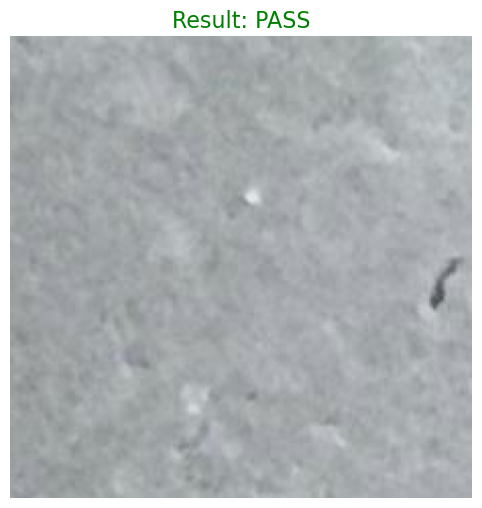

In [5]:
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt

# 1. Load trained model
model = YOLO("best.pt")  # your crack-detection model

# 2. Run inference
image_path = "00001.jpg"
results = model(image_path)  # list-like, one result per image
result = results[0]

# 3. Decide PASS/FAIL based on whether any 'crack' is detected
# crack class id = 1 (because names: [no_crack, crack])
CRACK_CLASS_ID = 1
CONF_THRESHOLD = 0.25  # adjust if needed

def get_pass_fail(res, crack_class_id=CRACK_CLASS_ID, conf_threshold=CONF_THRESHOLD):
    boxes = res.boxes
    if boxes is None or len(boxes) == 0:
        return "PASS"

    for b in boxes:
        cls_id = int(b.cls[0])
        conf = float(b.conf[0])
        if cls_id == crack_class_id and conf >= conf_threshold:
            return "FAIL"
    return "PASS"

status = get_pass_fail(result)
print("Inspection result:", status)  # PASS or FAIL

# 4. Plot image with bounding boxes drawn by YOLO
img_with_boxes = result.plot()  # numpy array with boxes

# Show using PIL + matplotlib so you can overlay the status if you like
pil_img = Image.fromarray(img_with_boxes)

plt.figure(figsize=(8, 6))
plt.imshow(pil_img)
plt.axis("off")
plt.title(f"Result: {status}", fontsize=16, color="red" if status == "FAIL" else "green")
plt.show()

In [6]:
from ultralytics import YOLO
import cv2

model = YOLO("best.pt")

CRACK_CLASS_ID = 1
CONF_THRESHOLD = 0.25  # adjust as needed

def classify_pass_fail(result, crack_class_id=CRACK_CLASS_ID, conf_threshold=CONF_THRESHOLD):
    """
    result: one YOLO result (results[0])
    returns "PASS" or "FAIL"
    """
    boxes = result.boxes
    if boxes is None or len(boxes) == 0:
        return "PASS"

    for b in boxes:
        cls_id = int(b.cls[0])
        conf = float(b.conf[0])
        if cls_id == crack_class_id and conf >= conf_threshold:
            return "FAIL"
    return "PASS"


cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Cannot open camera")
    exit()

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        # 1. Run YOLO on the current frame
        results = model(frame)
        result = results[0]

        # 2. Decide PASS/FAIL
        status = classify_pass_fail(result)

        # 3. Get annotated frame with bounding boxes
        annotated = result.plot()

        # 4. Overlay PASS/FAIL text on the frame
        if status == "FAIL":
            colour = (0, 0, 255)  # red (BGR)
        else:
            colour = (0, 255, 0)  # green

        cv2.putText(
            annotated,
            f"Status: {status}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            colour,
            2,
            cv2.LINE_AA
        )

        cv2.imshow("Defect Detection Demo", annotated)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):  # press 'q' to quit
            print("Stopping...")
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)  # helps macOS close window properly


0: 384x640 2 cracks, 45.7ms
Speed: 2.9ms preprocess, 45.7ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cracks, 47.7ms
Speed: 1.4ms preprocess, 47.7ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cracks, 55.3ms
Speed: 1.3ms preprocess, 55.3ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 crack, 48.9ms
Speed: 1.4ms preprocess, 48.9ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cracks, 46.6ms
Speed: 1.5ms preprocess, 46.6ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cracks, 41.2ms
Speed: 1.1ms preprocess, 41.2ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cracks, 40.8ms
Speed: 1.0ms preprocess, 40.8ms inference, 0.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cracks, 38.8ms
Speed: 1.2ms preprocess, 38.8ms inference, 0.3ms postprocess per image at shape (1, 3, 384

In [4]:
# Previous Live Demo
# from ultralytics import YOLO
# import cv2

# model = YOLO("best.pt")
# cap = cv2.VideoCapture(0)

# if not cap.isOpened():
#     print("Cannot open camera")
#     exit()

# try:
#     while True:
#         ret, frame = cap.read()
#         if not ret:
#             print("Failed to grab frame")
#             break

#         results = model(frame)
#         annotated = results[0].plot()

#         cv2.imshow("Defect Detection Demo", annotated)

#         key = cv2.waitKey(1) & 0xFF
#         if key == ord('q'):  # press 'q' to quit
#             print("Stopping...")
#             break

# finally:
#     cap.release()
#     cv2.destroyAllWindows()
#     cv2.waitKey(1)   # helps macOS close window properly

In [5]:
# Previous simple demo for image input
# Load trained model
# model = YOLO("best.pt")
# from PIL import Image
# results = model("test.jpg")
# img = results[0].plot()
# Image.fromarray(img)